In [81]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.colors as mcolors
import colorsys

import gseapy as gp
import graph_tool.all as gt
from scipy.cluster.hierarchy import linkage
import seaborn as sns
import pandas as pd
import matplotlib
import matplotlib.cm as cm

Import results from the u_vector notebook:

In [96]:

pij_pair_f = np.load('pij_pair_f.npy')
pij_pair_r = np.load('pij_pair_r.npy')
err_pij_pair_f = np.load('err_pij_pair_f.npy')
err_pij_pair_r = np.load('err_pij_pair_r.npy')
Aij_f = np.load('Aij_f.npy')
Aij_r = np.load('Aij_r.npy')

non_zero_cols_f = np.load('non_zero_cols_f.npy')
non_zero_cols_r = np.load('non_zero_cols_r.npy')
condensed_gene_perts = np.load('condensed_gene_perts.npy')
pert_column_ids = np.load('pert_column_ids.npy',allow_pickle=True) #is a numpy array but we need an index object
pert_column_ids = pd.DataFrame([],columns=pert_column_ids).columns #convert back to index object
gene_dict = np.load('gene_pert_dict.npy', allow_pickle=True)

A_new = np.load('A_new.npy')
gene_perts = pd.read_csv('gene_perts') #the gene perts series was saved as a df, need to convert
gene_perts.index = gene_perts.rid #make the index the rid
gene_perts = gene_perts.fin_genotype #now just get the series

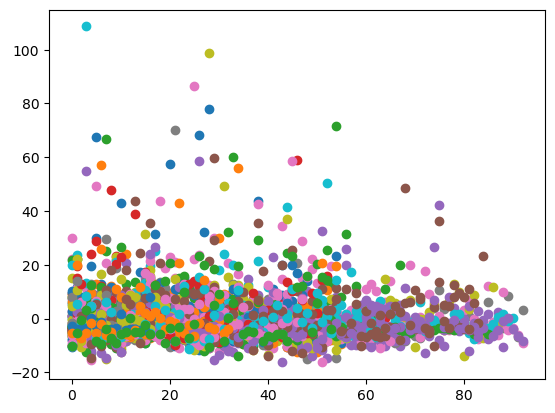

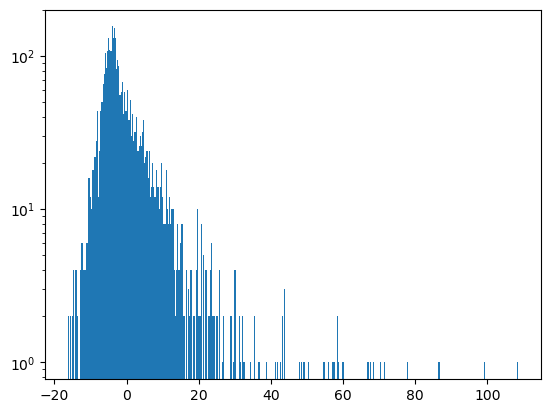

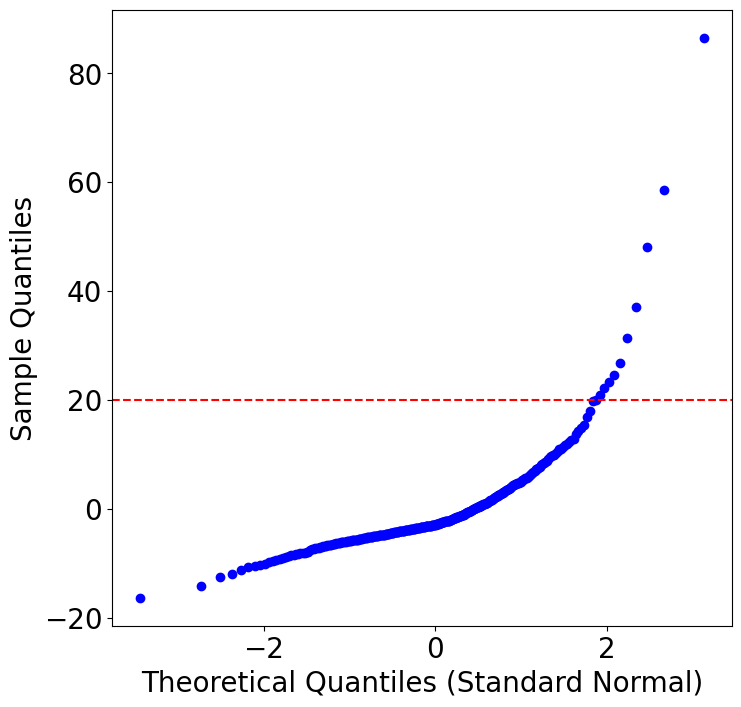

In [69]:
# forward
zitab_forward = np.zeros(np.shape(pij_pair_f))
for i in range(len(pij_pair_f)):
    for j in range(len(pij_pair_f[0])):
        if pij_pair_f[i][j]>0.001:
            if abs((Aij_f[i][j] - pij_pair_f[i][j])/err_pij_pair_f[i][j]) > 20:
                zitab_forward[i][j] = 1.
            
        
zvals = []       
for i in range(len(pij_pair_f)):

    ind = np.nonzero(pij_pair_f[i]>0.001)[0]
    if len(ind) > 0:
#     err_pij_pair[i][ind] = .0001
        plt.plot((Aij_f[i][ind] - pij_pair_f[i][ind])/err_pij_pair_f[i][ind], 'o')
        zvals.append((Aij_f[i][ind] - pij_pair_f[i][ind])/err_pij_pair_f[i][ind])

plt.show()

flat_zvals = []
for i in range(len(zvals)):
    for j in range(len(zvals[i])):
        flat_zvals.append(zvals[i][j])

plt.hist(flat_zvals, 400)
# plt.xscale('log')
plt.yscale('log')
plt.show()



# Generate a list of z-values (replace with your data)
# z_values = np.random.randn(100)  # Example: Random z-values for demonstration

# Sort the z-values
z_values_sorted = np.sort(flat_zvals)

# Calculate the expected quantiles for a standard normal distribution
n = len(z_values_sorted)
expected_quantiles = stats.norm.ppf(np.linspace(1/len(z_values_sorted), 1-1/len(z_values_sorted), len(z_values_sorted)))

# Create the Q-Q plot
plt.figure(figsize=(8, 8))
plt.scatter(expected_quantiles[::10], z_values_sorted[::10], c='b', marker='o', label='Observed')

# Set axis labels with fontsize 20
plt.xlabel('Theoretical Quantiles (Standard Normal)', fontsize=20)
plt.ylabel('Sample Quantiles', fontsize=20)

# Customize tick parameters
plt.tick_params(axis='both', which='major', labelsize=20)

# Add a horizontal line at y=50
plt.axhline(20, color='r', linestyle='--')

# Save the figure
plt.savefig('qqplot_aa_forward.pdf', bbox_inches='tight')

# Show the plot
plt.show()


NSD3 kd EDC4 kd

PAN3 kd TRIM71 kd

NR1I3 kd SUZ12 kd

GLIS3 kd STK11 kd

PAN3 kd CBFB kd

NSD3 kd GLIS3 kd

EDC4 kd MITF kd

GLIS3 kd MITF kd

EDC4 kd SMARCA4 kd

GLIS3 kd SMARCA4 kd

EED kd NR1I3 kd

ARID1A kd SLIRP kd

MITF kd ADAR oe

PAN3 kd ADAR oe

NSD3 kd PAN3 kd

TUT4 kd UNC5A kd

MAPK1 kd BCL11B kd

EED kd JUNB kd

ROR2 oe MAPK1 kd

NR1I3 kd EIF4A3 kd

ADAR oe TUT4 kd

PAN3 kd TUT4 kd

EDC4 kd CCND1 oe

GLIS3 kd SRRM4 oe

PAN3 kd SRRM4 oe

PAN3 kd CEBPA kd

GPD1 oe CEBPA kd

NR1I3 kd MED1 kd

TRIM71 kd FOXO1 kd

MAPK1 kd BMPR2 kd

JUNB kd RNF43 oe

TUT4 kd RNF43 oe

ADAR oe GPD1 oe

TUT4 kd GPD1 oe



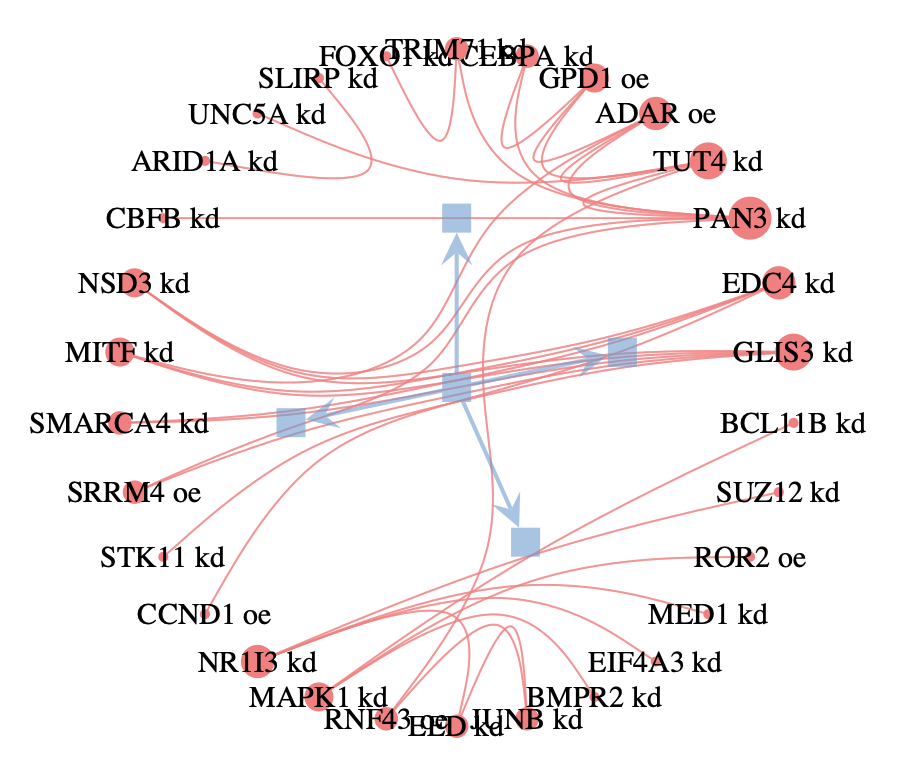

(<VertexPropertyMap object with value type 'vector<double>', for Graph 0x167027c50, at 0x1667bf540>,
 <GraphView object, directed, with 35 vertices and 34 edges, edges filtered by <EdgePropertyMap object with value type 'bool', for Graph 0x1676ff2f0, at 0x1667bf620>, vertices filtered by <VertexPropertyMap object with value type 'bool', for Graph 0x1676ff2f0, at 0x1667bcfa0>, at 0x1676ff2f0>,
 <VertexPropertyMap object with value type 'vector<double>', for Graph 0x1676ff2f0, at 0x1667be5f0>)

In [70]:
# forward


# Find pairs of nonzero indices
nonzero_pairs = np.transpose(np.nonzero(zitab_forward))
pairgenes_f = np.asarray(list(set(nonzero_pairs.flatten())))
# Create a mapping from original pair to renumbered pair
pair_mapping = {}
new_pair_id = 0

for pair in nonzero_pairs:
    pair = tuple(pair)
    if pair[0] != pair[1] and pair not in pair_mapping:
        if pair[0] not in pair_mapping:
            pair_mapping[pair[0]] = new_pair_id
            new_pair_id += 1
        if pair[1] not in pair_mapping:
            pair_mapping[pair[1]] = new_pair_id
            new_pair_id += 1


# Create a list of newly numbered pairs
newly_numbered_pairs = [(pair_mapping[pair[0]], pair_mapping[pair[1]]) for pair in nonzero_pairs if pair[0] != pair[1]]
reversed_pair_mapping = {v: k for k, v in pair_mapping.items()}


def create_graph_from_corr_matrix_gt(pairs):
    # Create an empty graph
    g = gt.Graph(directed=False)

    vertices = [g.add_vertex() for _ in range(1+max(np.array(pairs).flatten()))]
    gene_pairs_f = []
    gene_pairs_str_f = []
    for pair in pairs:
        
        i,j = pair
        e = g.add_edge(vertices[i], vertices[j])
        if i > j:
            str1 = condensed_gene_perts[non_zero_cols_f][reversed_pair_mapping[j]]
            str2 = condensed_gene_perts[non_zero_cols_f][reversed_pair_mapping[i]]
            if str1[:5] == 'SRRM2':
                str1 = 'SRRM2'
            if str2[:5] == 'SRRM2':
                str2 = 'SRRM2'
            print(str1 +' '+ str2)
            gene_pairs_f.append([i,j])
            gene_pairs_str_f.append([i,str1, j, str2])
            print()
           

    return g, gene_pairs_f, gene_pairs_str_f



g, gene_pairs_f, gene_pairs_str_f = create_graph_from_corr_matrix_gt(np.array(newly_numbered_pairs))
v_labels = g.new_vertex_property("string")
count = 0

for v in g.vertices():
    genestr = str(condensed_gene_perts[non_zero_cols_f][reversed_pair_mapping[count]])
    
    v_labels[v] = genestr
    count += 1
g.vertex_properties["labels"] = v_labels


# Create a vertex property map to store the colors
vertex_colors = g.new_vertex_property("string")

# Set all vertices to have the same color (blue)
default_color = "lightcoral"
for v in g.vertices():
    vertex_colors[v] = default_color

# Set the vertex property map as the vertex color property
g.vertex_properties["color"] = vertex_colors



state = gt.minimize_nested_blockmodel_dl(g)
state.draw(output_size=(450, 450),
           vertex_fill_color=g.vertex_properties["color"], vertex_color="lightcoral" ,vertex_text=g.vertex_properties["labels"],vertex_text_color='black',vertex_font_size=15,vertex_text_position=-3)

state.draw(output_size=(450, 450),
           vertex_fill_color=g.vertex_properties["color"], vertex_color="lightcoral" ,vertex_text=g.vertex_properties["labels"],vertex_text_color='black',vertex_font_size=15,vertex_text_position=-3,output="reverse_net_ib.pdf")
  

In [71]:
condensed_gene_perts=np.array(condensed_gene_perts)
condensed_gene_perts[non_zero_cols_f]

array(['NSD3 kd', 'WTAP kd', 'MYCN kd', 'TP63 kd', 'PROX1 oe', 'PROX1 kd',
       'RNF40 kd', 'EDC4 kd', 'IKBKB kd', 'ARID1A kd', 'EZH2 kd',
       'EZH2 oe', 'TRIM71 kd', 'STAU1 oe', 'TFEB kd', 'ERG oe',
       'METTL3 kd', 'POU5F1 oe', 'METTL14 kd', 'VIRMA kd', 'ADAR kd',
       'BEGAIN kd', 'CCNK kd', 'DPPA5 kd', 'GLI1 kd', 'JAK2 kd',
       'POLR2D kd', 'PSMD13 kd', 'TGM5 kd', 'TOX4 kd', 'CDX2 oe',
       'CEBPA oe', 'EGR1 oe', 'ETV2 oe', 'FLI1 oe', 'FOXC2 oe',
       'FOXF1 oe', 'GATA1 oe', 'GATA2 oe', 'GATA3 oe', 'HHEX oe',
       'LMO2 oe', 'LYL1 oe', 'NFE2 oe', 'SPI1 oe', 'EED kd', 'EZH1 kd',
       'SUZ12 kd', 'STK11 kd', 'DKC1 kd', 'AFF4 kd', 'CBFB kd', 'ERG kd',
       'GLIS3 kd', 'HNRNPF kd', 'RBPJ kd', 'TCF3 kd', 'MITF kd',
       'SMARCA4 kd', 'RELA oe', 'U2AF1 oe', 'SLC9A3R2 kd', 'ABL1 kd',
       'ABL2 kd', 'NR1I3 kd', 'ROR2 oe', 'MIR1343 oe', 'FUS kd',
       'SLIRP kd', 'MIR126 kd', 'COP1 kd', 'MIR29A kd', 'ADARB1 kd',
       'ADAR oe', 'ADARB1 oe', 'PAN3 kd', 'AIMP2 

In [72]:
print(pairgenes_f)
pairgenes_f = []
for i in range(len(nonzero_pairs)):
    gene1, gene2 = nonzero_pairs[i]
    if gene1 != gene2:
        pairgenes_f.append(gene1)
        pairgenes_f.append(gene2)

pairgenes_f = np.asarray(list(set(pairgenes_f)))
print(pairgenes_f)

[  0 128 131   5 134   7   9 139  12  13  14 143  16  17  20  29  45  47
  48  51  53  57  58  60  64  65  68  69  70  73  75  77  81  82  84  88
  89  91  93  95  97 102 104 111 112 114 121 127]
[  0 134   7   9 139  12 143  45  47  48  51  53  57  58  64  65  68  73
  75  81  82  88  89  93  95 102 111 114 121 127]


In [73]:
## convert perts to genes and get gene indices

unique_gene_perts = condensed_gene_perts

input_genes = unique_gene_perts.copy()
for i in range(len(input_genes)):
    input_genes[i] = input_genes[i][:-3]

perts_to_eid = {
    gene: item['element']
    for gene in input_genes
    for item in gene_dict
    if gene in item['last_two_words']
}
pert_to_gene_indices = {gene: pert_column_ids.get_loc(eid) for gene, eid in perts_to_eid.items() if eid in pert_column_ids}

    
common_top_genes_f_and_r = condensed_gene_perts[non_zero_cols_f][pairgenes_f] 
for i in range(len(common_top_genes_f_and_r)):
    common_top_genes_f_and_r[i] = common_top_genes_f_and_r[i][:-3]
# Assuming common_top_genes_f_and_r is a list of genes and pert_to_gene_indices is the dictionary mapping genes to indices

# List to store corresponding gene indices
common_top_gene_indices_f_and_r, common_top_pert_indices_f_and_r = [], []
count  = 0
finalgenes = []
# Iterate over each gene in common_top_genes_f_and_r
for gene in common_top_genes_f_and_r:
    # Check if the gene exists in pert_to_gene_indices
    if gene in pert_to_gene_indices:
        # Append the corresponding index to the list
        finalgenes.append(gene)
        common_top_gene_indices_f_and_r.append(pert_to_gene_indices[gene])
        common_top_pert_indices_f_and_r.append(pairgenes_f[count])
    else: print(gene)
    count += 1

# Print the list of gene indices
print("Corresponding gene indices:", common_top_gene_indices_f_and_r)
print("Corresponding pert indices:", common_top_pert_indices_f_and_r)

MITF
SMARCA4
UNC5A
SRRM4
Corresponding gene indices: [29775, 35381, 39659, 4429, 48649, 45401, 50668, 31161, 14890, 23799, 45, 3892, 28736, 2141, 11059, 49119, 47541, 32156, 9147, 29914, 16228, 32088, 35387, 31338, 50637, 37096]
Corresponding pert indices: [np.int64(0), np.int64(134), np.int64(7), np.int64(9), np.int64(139), np.int64(12), np.int64(143), np.int64(45), np.int64(47), np.int64(48), np.int64(51), np.int64(53), np.int64(64), np.int64(65), np.int64(68), np.int64(73), np.int64(75), np.int64(82), np.int64(88), np.int64(89), np.int64(93), np.int64(95), np.int64(102), np.int64(114), np.int64(121), np.int64(127)]


In [74]:
# Example lists for demonstration

# Create the finalgenes_ann list
finalgenes_ann = []

# Populate finalgenes_ann with corresponding annotations from condensed_gene_perts
for gene in finalgenes:
    for annotated_gene in condensed_gene_perts:
        if gene in annotated_gene:
            finalgenes_ann.append(annotated_gene)
            break

# Print the finalgenes_ann list
print("\nFinalgenes_ann list with annotations:")
print(finalgenes_ann)



Finalgenes_ann list with annotations:
[np.str_('NSD3 kd'), np.str_('BMPR2 oe'), np.str_('EDC4 kd'), np.str_('ARID1A kd'), np.str_('RNF43 oe'), np.str_('TRIM71 kd'), np.str_('GPD1 oe'), np.str_('EED kd'), np.str_('SUZ12 kd'), np.str_('STK11 kd'), np.str_('CBFB oe'), np.str_('GLIS3 kd'), np.str_('NR1I3 kd'), np.str_('ROR2 oe'), np.str_('SLIRP kd'), np.str_('ADAR kd'), np.str_('PAN3 kd'), np.str_('BCL11B kd'), np.str_('JUNB kd'), np.str_('MAPK1 kd'), np.str_('EIF4A3 kd'), np.str_('TUT4 kd'), np.str_('CCND1 oe'), np.str_('CEBPA oe'), np.str_('MED1 kd'), np.str_('FOXO1 kd')]


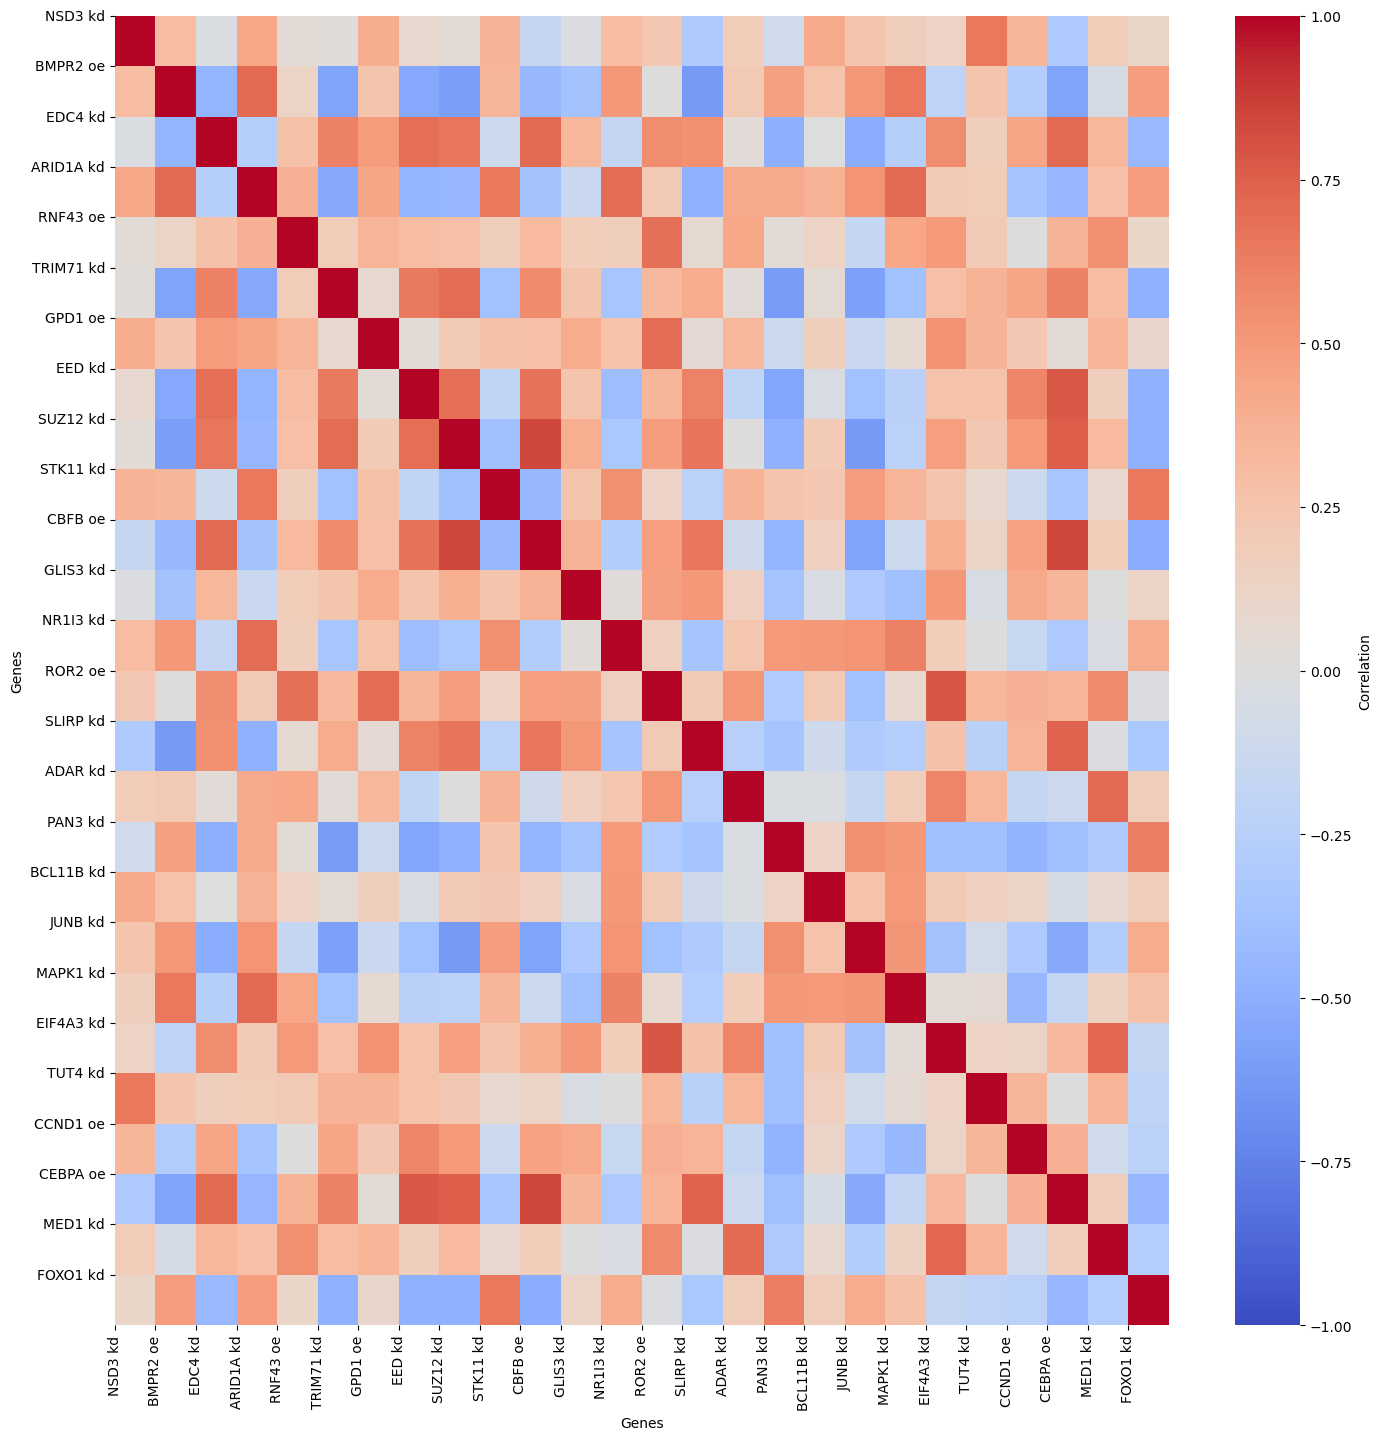

In [75]:
#make a heatmap with correlations of perturbation responses

# Assuming 'gene_labels' is a list of gene labels corresponding to 'common_top_gene_indices_f_and_r'
gene_labels = finalgenes_ann  # replace with actual gene labels


A = A_new
Acorr = np.corrcoef(A[common_top_pert_indices_f_and_r][:, common_top_gene_indices_f_and_r], rowvar=False)

fig, axs = plt.subplots(1, 1, figsize=(17, 17))

sns.heatmap(Acorr, cmap='coolwarm', ax=axs, cbar_kws={'label': 'Correlation'},vmin=-1, vmax=1)
axs.set_xlabel('Genes')
axs.set_ylabel('Genes')
# axs.set_zlim(-1, 1)

# Add gene labels after plotting the heatmap
axs.set_xticks(range(len(gene_labels)))
axs.set_yticks(range(len(gene_labels)))
axs.set_xticklabels(gene_labels, rotation=90, ha="center")
axs.set_yticklabels(gene_labels, rotation=0, va="center")

plt.show()

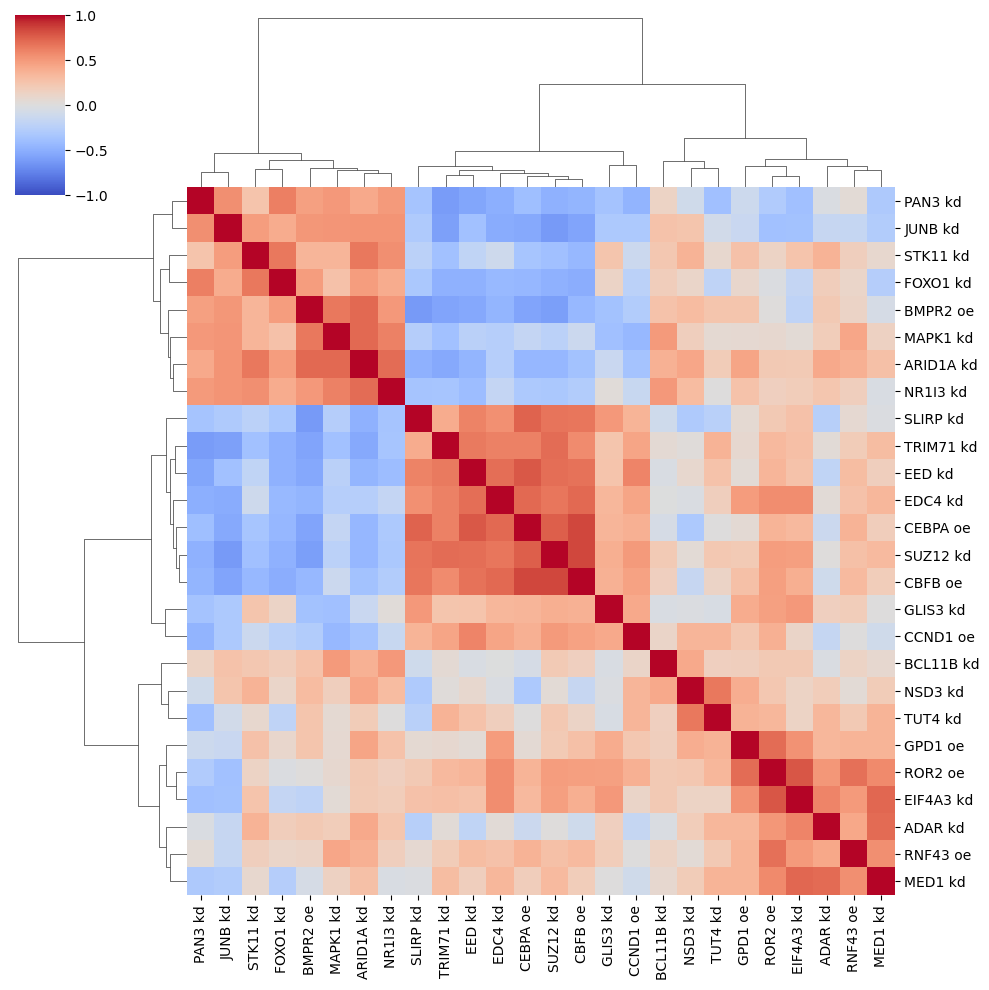

In [76]:
#same figure as above, but clustered

# Your correlation matrix and a list of labels corresponding to the indices

# Creating the linkage matrix for clustering
row_linkage = linkage(Acorr, method='ward')
col_linkage = linkage(Acorr.T, method='ward')  # Transpose for column clustering

# Creating a clustermap with labels
sns.clustermap(Acorr, cmap='coolwarm', figsize=(10, 10),
               row_cluster=True, col_cluster=True,
               row_linkage=row_linkage, col_linkage=col_linkage,
               xticklabels=gene_labels, yticklabels=gene_labels,vmin=-1, vmax=1)
plt.show()


In [77]:
print(pairgenes_f)
pairgenes_f = []
for i in range(len(nonzero_pairs)):
    gene1, gene2 = nonzero_pairs[i]
    if gene1 != gene2:
        pairgenes_f.append(gene1)
        pairgenes_f.append(gene2)

pairgenes_f = np.asarray(list(set(pairgenes_f)))
print(pairgenes_f)

gene_pair_index_f = []
for pair in gene_pairs_f:
    i,j = pair
    gene_pair_index_f.append([reversed_pair_mapping[i], reversed_pair_mapping[j]])
print(gene_pair_index_f)

[  0 134   7   9 139  12 143  45  47  48  51  53  57  58  64  65  68  73
  75  81  82  88  89  93  95 102 111 114 121 127]
[  0 134   7   9 139  12 143  45  47  48  51  53  57  58  64  65  68  73
  75  81  82  88  89  93  95 102 111 114 121 127]
[[np.int64(7), np.int64(0)], [np.int64(12), np.int64(75)], [np.int64(47), np.int64(64)], [np.int64(48), np.int64(53)], [np.int64(51), np.int64(75)], [np.int64(53), np.int64(0)], [np.int64(57), np.int64(7)], [np.int64(57), np.int64(53)], [np.int64(58), np.int64(7)], [np.int64(58), np.int64(53)], [np.int64(64), np.int64(45)], [np.int64(68), np.int64(9)], [np.int64(73), np.int64(57)], [np.int64(73), np.int64(75)], [np.int64(75), np.int64(0)], [np.int64(81), np.int64(95)], [np.int64(82), np.int64(89)], [np.int64(88), np.int64(45)], [np.int64(89), np.int64(65)], [np.int64(93), np.int64(64)], [np.int64(95), np.int64(73)], [np.int64(95), np.int64(75)], [np.int64(102), np.int64(7)], [np.int64(111), np.int64(53)], [np.int64(111), np.int64(75)], [np.int6

In [78]:

unique_gene_perts = np.asarray(list(set(gene_perts)))

# input_genes = unique_gene_perts
input_genes = condensed_gene_perts.copy()
for i in range(len(input_genes)):
    input_genes[i] = input_genes[i][:-3]

perts_to_eid = {
    gene: item['element']
    for gene in input_genes
    for item in gene_dict
    if gene in item['last_two_words']
#     if gene in item['last_two_words'].split(',')
}
pert_to_gene_indices = {gene: pert_column_ids.get_loc(eid) for gene, eid in perts_to_eid.items() if eid in pert_column_ids}

    
common_top_genes_f_and_r = condensed_gene_perts[non_zero_cols_f][pairgenes_f]
for i in range(len(common_top_genes_f_and_r)):
    common_top_genes_f_and_r[i] = common_top_genes_f_and_r[i][:-3]
# Assuming common_top_genes_f_and_r is a list of genes and pert_to_gene_indices is the dictionary mapping genes to indices

# List to store corresponding gene indices
common_top_gene_indices_f_and_r, common_top_pert_indices_f_and_r = [], []
count  = 0
finalgenes, finalgeneindex = [], []
# Iterate over each gene in common_top_genes_f_and_r
for gene in common_top_genes_f_and_r:
    # Check if the gene exists in pert_to_gene_indices
    if gene in pert_to_gene_indices:
        # Append the corresponding index to the list
        finalgenes.append(gene)
        finalgeneindex.append(pairgenes_f[count])
        common_top_gene_indices_f_and_r.append(pert_to_gene_indices[gene])
        common_top_pert_indices_f_and_r.append(pairgenes_f[count])
    else: print(gene)
    count += 1

# Print the list of gene indices
print("Corresponding gene indices:", common_top_gene_indices_f_and_r)
print("Corresponding pert indices:", common_top_pert_indices_f_and_r)

indtoind  = {finalgeneindex[i]: i for i in range(len(finalgeneindex))}

count = 0
newpairs = []
for pair in gene_pair_index_f:
    i,j = pair
    if i in finalgeneindex and j in finalgeneindex:
        newind1, newind2 = indtoind[i], indtoind[j]
        newpairs.append([newind1, newind2])
        count += 1
    else: print(i,j)


MITF
SMARCA4
UNC5A
SRRM4
Corresponding gene indices: [29775, 35381, 39659, 4429, 48649, 45401, 50668, 31161, 14890, 23799, 45, 3892, 28736, 2141, 11059, 49119, 47541, 32156, 9147, 29914, 16228, 32088, 35387, 31338, 50637, 37096]
Corresponding pert indices: [np.int64(0), np.int64(134), np.int64(7), np.int64(9), np.int64(139), np.int64(12), np.int64(143), np.int64(45), np.int64(47), np.int64(48), np.int64(51), np.int64(53), np.int64(64), np.int64(65), np.int64(68), np.int64(73), np.int64(75), np.int64(82), np.int64(88), np.int64(89), np.int64(93), np.int64(95), np.int64(102), np.int64(114), np.int64(121), np.int64(127)]
57 7
57 53
58 7
58 53
73 57
81 95
111 53
111 75


In [79]:
# reverse

def create_graph_from_corr_matrix_gt(pairs, newfingenes):
    # Create an empty graph
    g = gt.Graph(directed=False)
#     vertices = [g.add_vertex() for _ in range(1+max(np.array(pairs).flatten()))]
    vertices = [g.add_vertex() for _ in range(len(newfingenes))]
    
    gene_pairs_r = []
    
    weights = g.new_edge_property("double")
    count = 0
#     print(pairs)
    gene_pairs_f = []
    for pair in pairs:
        i,j = pair
        e = g.add_edge(vertices[i], vertices[j])
        weights[e] = Acorr[i][j]
        count += 1
        print(count, finalgenes[i] +' '+ finalgenes[j])
        gene_pairs_f.append(finalgenes[i] +' '+ finalgenes[j])

        
        
    g.edge_properties["weight"] = weights
    
     
    
    return g, weights, gene_pairs_f

g, weights,gene_pairs_f_final = create_graph_from_corr_matrix_gt(np.array(newpairs), finalgenes)
v_labels = g.new_vertex_property("string")
count = 0
for v in g.vertices():
#     print('vertex v = ', v)
    genestr = finalgenes[count]
    v_labels[v] = genestr

    count += 1
g.vertex_properties["labels"] = v_labels

# Create a vertex property map to store the colors
vertex_colors = g.new_vertex_property("string")

oe_color = "indianred"
kd_color = "slateblue"

1 EDC4 NSD3
2 TRIM71 PAN3
3 SUZ12 NR1I3
4 STK11 GLIS3
5 CBFB PAN3
6 GLIS3 NSD3
7 NR1I3 EED
8 SLIRP ARID1A
9 ADAR PAN3
10 PAN3 NSD3
11 BCL11B MAPK1
12 JUNB EED
13 MAPK1 ROR2
14 EIF4A3 NR1I3
15 TUT4 ADAR
16 TUT4 PAN3
17 CCND1 EDC4
18 CEBPA PAN3
19 CEBPA GPD1
20 MED1 NR1I3
21 FOXO1 TRIM71
22 BMPR2 MAPK1
23 RNF43 JUNB
24 RNF43 TUT4
25 GPD1 ADAR
26 GPD1 TUT4


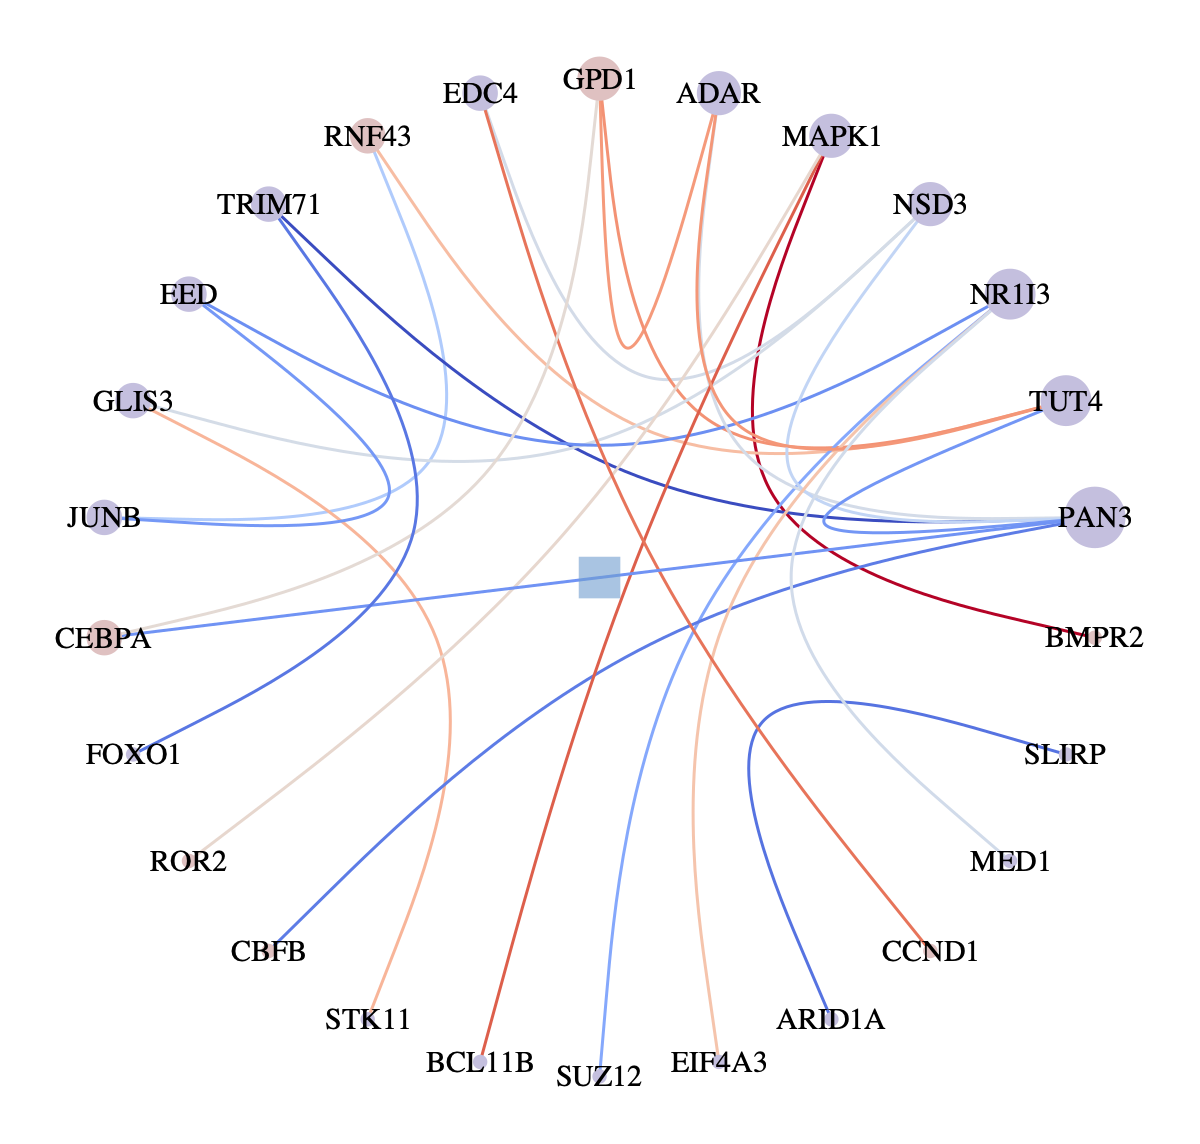

(<VertexPropertyMap object with value type 'vector<double>', for Graph 0x164fefe30, at 0x166fa5a20>,
 <GraphView object, directed, with 27 vertices and 26 edges, edges filtered by <EdgePropertyMap object with value type 'bool', for Graph 0x166f980f0, at 0x166fa6820>, vertices filtered by <VertexPropertyMap object with value type 'bool', for Graph 0x166f980f0, at 0x166fa6580>, at 0x166f980f0>,
 <VertexPropertyMap object with value type 'vector<double>', for Graph 0x166f980f0, at 0x166fa6b30>)

In [82]:
# Function to adjust hue to pastel
def make_pastel(color):
    rgb = mcolors.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(*rgb)
    s *= 0.6  # Reduce saturation
    l *= 1.4  # Increase lightness
    l = min(l, 1.0)  # Ensure lightness does not exceed 1.0
    pastel_rgb = colorsys.hls_to_rgb(h, l, s)
    return pastel_rgb

# Adjust colors to pastel
oe_color_pastel = make_pastel(oe_color)
kd_color_pastel = make_pastel(kd_color)

# Apply colors to vertices
vertex_colors = g.new_vertex_property("vector<float>")
count = 0
for v in g.vertices():
    if finalgenes_ann[count][-2:] == 'kd':
        vertex_colors[v] = kd_color_pastel
    else:
        vertex_colors[v] = oe_color_pastel
    count += 1

# Set the vertex property map as the vertex color property
g.vertex_properties["color"] = vertex_colors


state = gt.minimize_nested_blockmodel_dl(g,
                                         state_args=dict(base_type=gt.LayeredBlockState,
                                                         state_args=dict(ec=weights, layers=False)))

# state = gt.minimize_nested_blockmodel_dl(g)

state.draw(edge_color=g.ep.weight, edge_gradient=[],
           ecmap=(matplotlib.cm.coolwarm, 1.), edge_pen_width=1.5,
           output_size=(600, 600),vertex_fill_color=g.vertex_properties["color"], vertex_color=g.vertex_properties["color"] ,\
           vertex_text=g.vertex_properties["labels"],\
           vertex_text_color='black',vertex_font_size=15,vertex_text_position=-3)

state.draw(edge_color=g.ep.weight, edge_gradient=[],
           ecmap=(matplotlib.cm.coolwarm, 1.), edge_pen_width=1.5,
           output_size=(500, 500),vertex_fill_color=g.vertex_properties["color"], vertex_color=g.vertex_properties["color"] ,\
           vertex_text=g.vertex_properties["labels"],\
           vertex_text_color='black',vertex_font_size=15,vertex_text_position=-3, output="forward_net_ib.pdf")

        

    

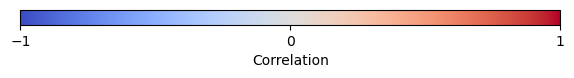

In [98]:




# Create scalar mappable
sm = cm.ScalarMappable(cmap='coolwarm', norm=mcolors.Normalize(vmin=-1, vmax=1))
sm.set_array([])

# Make a figure and an axis *just* for the colorbar
fig = plt.figure(figsize=(6, 1))
cbar_ax = fig.add_axes([0.05, 0.5, 0.9, 0.15])  # [left, bottom, width, height]

# Add colorbar to that axis
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal', ticks=[-1, 0, 1])
cbar.set_label('Correlation')

fig.savefig('colorbar.pdf', bbox_inches='tight', pad_inches=0)
plt.show()
plt.close(fig)


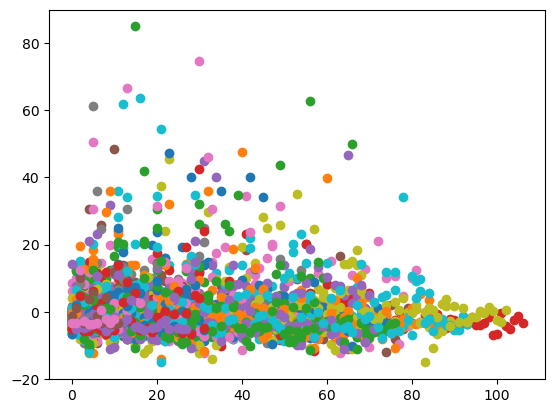

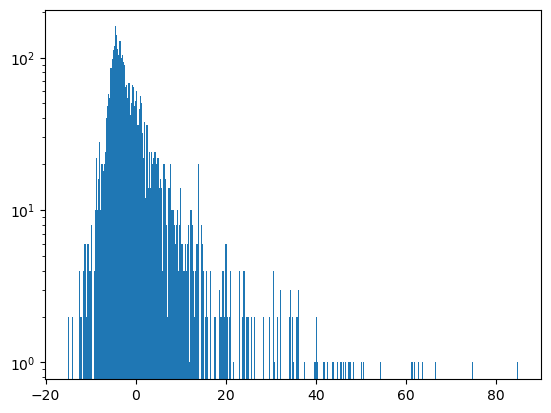

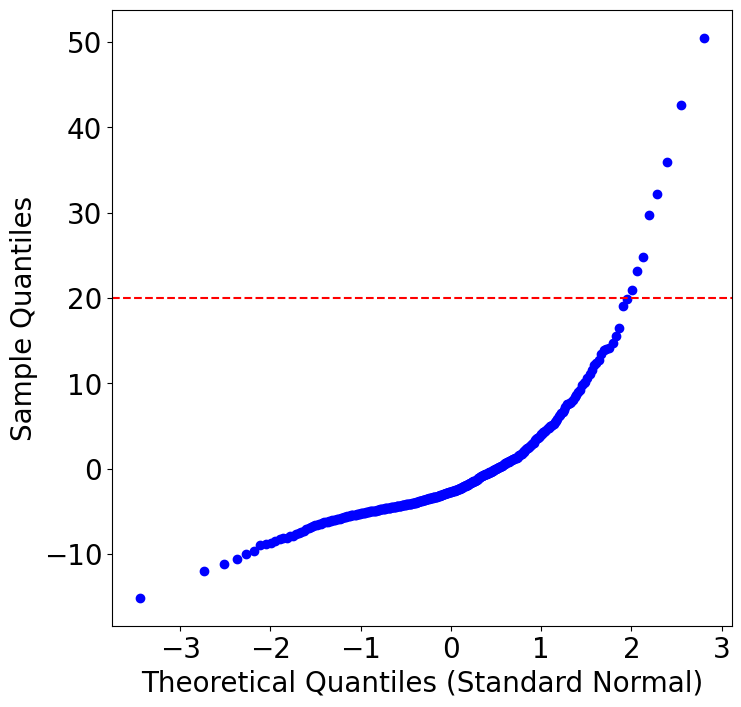

In [84]:
# reverse
zitab_reverse = np.zeros(np.shape(pij_pair_r))
for i in range(len(pij_pair_r)):
    for j in range(len(pij_pair_r[0])):
        if pij_pair_r[i][j]>0.001:
            if abs((Aij_r[i][j] - pij_pair_r[i][j])/err_pij_pair_r[i][j]) > 20:
                zitab_reverse[i][j] = 1.
            
        
zvals = []       
for i in range(len(pij_pair_r)):

    ind = np.nonzero(pij_pair_r[i]>0.001)[0]
    if len(ind) > 0:
#     err_pij_pair[i][ind] = .0001
        plt.plot((Aij_r[i][ind] - pij_pair_r[i][ind])/err_pij_pair_r[i][ind], 'o')
        zvals.append((Aij_r[i][ind] - pij_pair_r[i][ind])/err_pij_pair_r[i][ind])

plt.show()

flat_zvals = []
for i in range(len(zvals)):
    for j in range(len(zvals[i])):
        flat_zvals.append(zvals[i][j])

plt.hist(flat_zvals, 400)
# plt.xscale('log')
plt.yscale('log')
plt.show()



# Generate a list of z-values (replace with your data)
# z_values = np.random.randn(100)  # Example: Random z-values for demonstration

# Sort the z-values
z_values_sorted = np.sort(flat_zvals)

# Calculate the expected quantiles for a standard normal distribution
n = len(z_values_sorted)
expected_quantiles = stats.norm.ppf(np.linspace(1/len(z_values_sorted), 1-1/len(z_values_sorted), len(z_values_sorted)))

# Create the Q-Q plot
plt.figure(figsize=(8, 8))
plt.scatter(expected_quantiles[::10], z_values_sorted[::10], c='b', marker='o', label='Observed')

# Set axis labels with fontsize 20
plt.xlabel('Theoretical Quantiles (Standard Normal)', fontsize=20)
plt.ylabel('Sample Quantiles', fontsize=20)

# Customize tick parameters
plt.tick_params(axis='both', which='major', labelsize=20)

# Add a horizontal line at y=50
plt.axhline(20, color='r', linestyle='--')

# Save the figure
plt.savefig('qqplot_aa_reverse.pdf', bbox_inches='tight')

# Show the plot
plt.show()


DPPA5 kd JAK2 kd
IKBKB kd CDX2 oe
SART3 kd EED kd
EED kd SUZ12 kd
CCND1 oe GLIS3 kd
PAN3 kd MITF kd
CCND1 oe MITF kd
TCF3 kd SMARCA4 kd
SUZ12 kd NR1I3 kd
SART3 kd NR1I3 kd
CCND1 oe COP1 kd
GLIS3 kd PAN3 kd
COP1 kd RNF20 kd
SART3 kd RNF20 kd
SART3 kd UNC5A kd
SUZ12 kd JUNB kd
SART3 kd JUNB kd
SUZ12 kd MAPK1 kd
SUZ12 kd EIF4A3 kd
ADAR kd CCND1 oe
COP1 kd MYC oe
SUZ12 kd TENT4B oe
CDX2 oe ALDH1A1 kd
EDC4 kd RPS6KB2 kd
COP1 kd FOXO1 kd
DPPA5 kd SART3 kd
JAK2 kd SART3 kd
JAK2 kd BPIFB3 kd


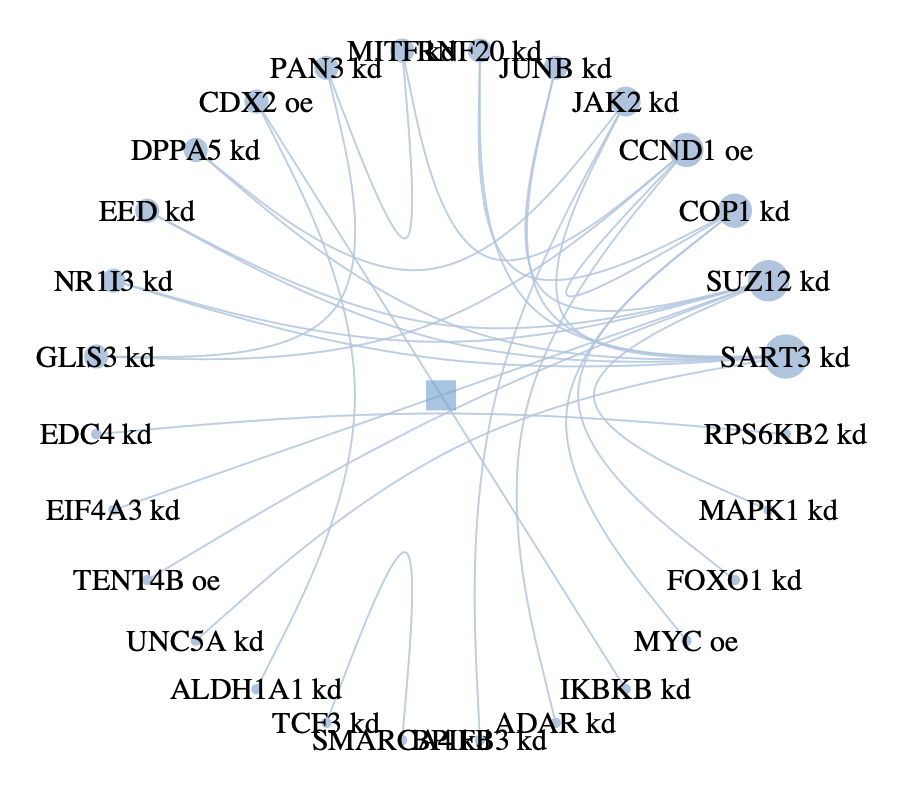

(<VertexPropertyMap object with value type 'vector<double>', for Graph 0x167a88e10, at 0x1672f8050>,
 <GraphView object, directed, with 29 vertices and 28 edges, edges filtered by <EdgePropertyMap object with value type 'bool', for Graph 0x1672ec230, at 0x167311160>, vertices filtered by <VertexPropertyMap object with value type 'bool', for Graph 0x1672ec230, at 0x167310d70>, at 0x1672ec230>,
 <VertexPropertyMap object with value type 'vector<double>', for Graph 0x1672ec230, at 0x167311f60>)

In [85]:
# reverse

# Find pairs of nonzero indices
nonzero_pairs = np.transpose(np.nonzero(zitab_reverse))
pairgenes_r = np.asarray(list(set(nonzero_pairs.flatten())))

# Create a mapping from original pair to renumbered pair
pair_mapping = {}
new_pair_id = 0

for pair in nonzero_pairs:
    pair = tuple(pair)
    if pair[0] != pair[1] and pair not in pair_mapping:
        if pair[0] not in pair_mapping:
            pair_mapping[pair[0]] = new_pair_id
            new_pair_id += 1
        if pair[1] not in pair_mapping:
            pair_mapping[pair[1]] = new_pair_id
            new_pair_id += 1

# Create a list of newly numbered pairs
newly_numbered_pairs = [(pair_mapping[pair[0]], pair_mapping[pair[1]]) for pair in nonzero_pairs if pair[0] != pair[1]]
reversed_pair_mapping = {v: k for k, v in pair_mapping.items()}



def create_graph_from_corr_matrix_gt(pairs):
    # Create an empty graph
    g = gt.Graph(directed=False)

    vertices = [g.add_vertex() for _ in range(1+max(np.array(pairs).flatten()))]
    gene_pairs_r = []
    for pair in pairs:
        
        i,j = pair
        e = g.add_edge(vertices[i], vertices[j])
        if i > j:
            str1 = condensed_gene_perts[non_zero_cols_r][reversed_pair_mapping[j]]
            str2 = condensed_gene_perts[non_zero_cols_r][reversed_pair_mapping[i]]
            if str1[:5] == 'SRRM2':
                str1 = 'SRRM2'
            if str2[:5] == 'SRRM2':
                str2 = 'SRRM2'
            print(str1 +' '+ str2)
            gene_pairs_r.append([i,j])

           

    return g, gene_pairs_r




g, gene_pairs_r = create_graph_from_corr_matrix_gt(np.array(newly_numbered_pairs))
v_labels = g.new_vertex_property("string")
count = 0
for v in g.vertices():
    genestr = str(condensed_gene_perts[non_zero_cols_r][reversed_pair_mapping[count]])
    v_labels[v] = genestr
    count += 1
g.vertex_properties["labels"] = v_labels


# Create a vertex property map to store the colors
vertex_colors = g.new_vertex_property("string")

# Set all vertices to have the same color (blue)
default_color = "lightsteelblue"
for v in g.vertices():
    vertex_colors[v] = default_color

# Set the vertex property map as the vertex color property
g.vertex_properties["color"] = vertex_colors



state = gt.minimize_nested_blockmodel_dl(g)
state.draw(output_size=(450, 450),
           vertex_fill_color=g.vertex_properties["color"], vertex_color="lightsteelblue" ,
           vertex_text=g.vertex_properties["labels"],vertex_text_color='black',
           vertex_font_size=15,vertex_text_position=-3)

state.draw(output_size=(450, 450),
           vertex_fill_color=g.vertex_properties["color"], vertex_color="lightsteelblue" ,
           vertex_text=g.vertex_properties["labels"],vertex_text_color='black',vertex_font_size=15,
           vertex_text_position=-3,output="reverse_net_ib.pdf")


In [86]:
print(pairgenes_r)
pairgenes_r = []
genepairs_r = []
for i in range(len(nonzero_pairs)):
    gene1, gene2 = nonzero_pairs[i]
    if gene1 != gene2:
        genepairs_r.append([gene1, gene2])
        pairgenes_r.append(gene1)
        pairgenes_r.append(gene2)

pairgenes_r = np.asarray(list(set(pairgenes_r)))
print(pairgenes_r)
print(genepairs_r)

[129 130 134   6   8   7 137 140  17 146  20 150  23  25  34  36  38  41
  48  50  51  54  57  58  59  60  66  67  68  75  77  84  85  87  91 103
 104 106 109 111 113 115 117 118 125]
[130 134   7   8 137 146  20 150  23  25  34  48  50  54  58  59  60  68
  77  85  87  91 103 104 109 115 117 125]
[[np.int64(7), np.int64(134)], [np.int64(8), np.int64(34)], [np.int64(20), np.int64(115)], [np.int64(23), np.int64(25)], [np.int64(23), np.int64(146)], [np.int64(25), np.int64(23)], [np.int64(25), np.int64(146)], [np.int64(25), np.int64(150)], [np.int64(34), np.int64(8)], [np.int64(34), np.int64(130)], [np.int64(48), np.int64(50)], [np.int64(48), np.int64(146)], [np.int64(50), np.int64(48)], [np.int64(50), np.int64(68)], [np.int64(50), np.int64(103)], [np.int64(50), np.int64(104)], [np.int64(50), np.int64(109)], [np.int64(50), np.int64(125)], [np.int64(54), np.int64(85)], [np.int64(54), np.int64(115)], [np.int64(58), np.int64(60)], [np.int64(59), np.int64(85)], [np.int64(59), np.int64(115)], 

In [87]:

unique_gene_perts = np.asarray(list(set(gene_perts)))

input_genes = condensed_gene_perts.copy()
for i in range(len(input_genes)):
    input_genes[i] = input_genes[i][:-3]

perts_to_eid = {
    gene: item['element']
    for gene in input_genes
    for item in gene_dict
    if gene in item['last_two_words']
#     if gene in item['last_two_words'].split(',')
}
pert_to_gene_indices = {gene: pert_column_ids.get_loc(eid) for gene, eid in perts_to_eid.items() if eid in pert_column_ids}

    
common_top_genes_f_and_r = condensed_gene_perts[non_zero_cols_r][pairgenes_r]
for i in range(len(common_top_genes_f_and_r)):
    common_top_genes_f_and_r[i] = common_top_genes_f_and_r[i][:-3]    
# Assuming common_top_genes_f_and_r is a list of genes and pert_to_gene_indices is the dictionary mapping genes to indices

# List to store corresponding gene indices
common_top_gene_indices_f_and_r, common_top_pert_indices_f_and_r = [], []
count  = 0
finalgenes = []
# Iterate over each gene in common_top_genes_f_and_r
for gene in common_top_genes_f_and_r:
    # Check if the gene exists in pert_to_gene_indices
    if gene in pert_to_gene_indices:
        # Append the corresponding index to the list
        finalgenes.append(gene)
        common_top_gene_indices_f_and_r.append(pert_to_gene_indices[gene])
        common_top_pert_indices_f_and_r.append(pairgenes_r[count])
    else: print(gene)
    count += 1

# Print the list of gene indices
print("Corresponding gene indices:", common_top_gene_indices_f_and_r)
print("Corresponding pert indices:", common_top_pert_indices_f_and_r)

IKBKB
MITF
SMARCA4
COP1
UNC5A
Corresponding gene indices: [4599, 50587, 39659, 37096, 21867, 49119, 48645, 48118, 6233, 43302, 31161, 14890, 3892, 40172, 28736, 47541, 35441, 9147, 29914, 16228, 35387, 50014, 40433]
Corresponding pert indices: [np.int64(130), np.int64(134), np.int64(7), np.int64(137), np.int64(146), np.int64(20), np.int64(150), np.int64(23), np.int64(25), np.int64(34), np.int64(48), np.int64(50), np.int64(54), np.int64(58), np.int64(68), np.int64(85), np.int64(87), np.int64(103), np.int64(104), np.int64(109), np.int64(115), np.int64(117), np.int64(125)]


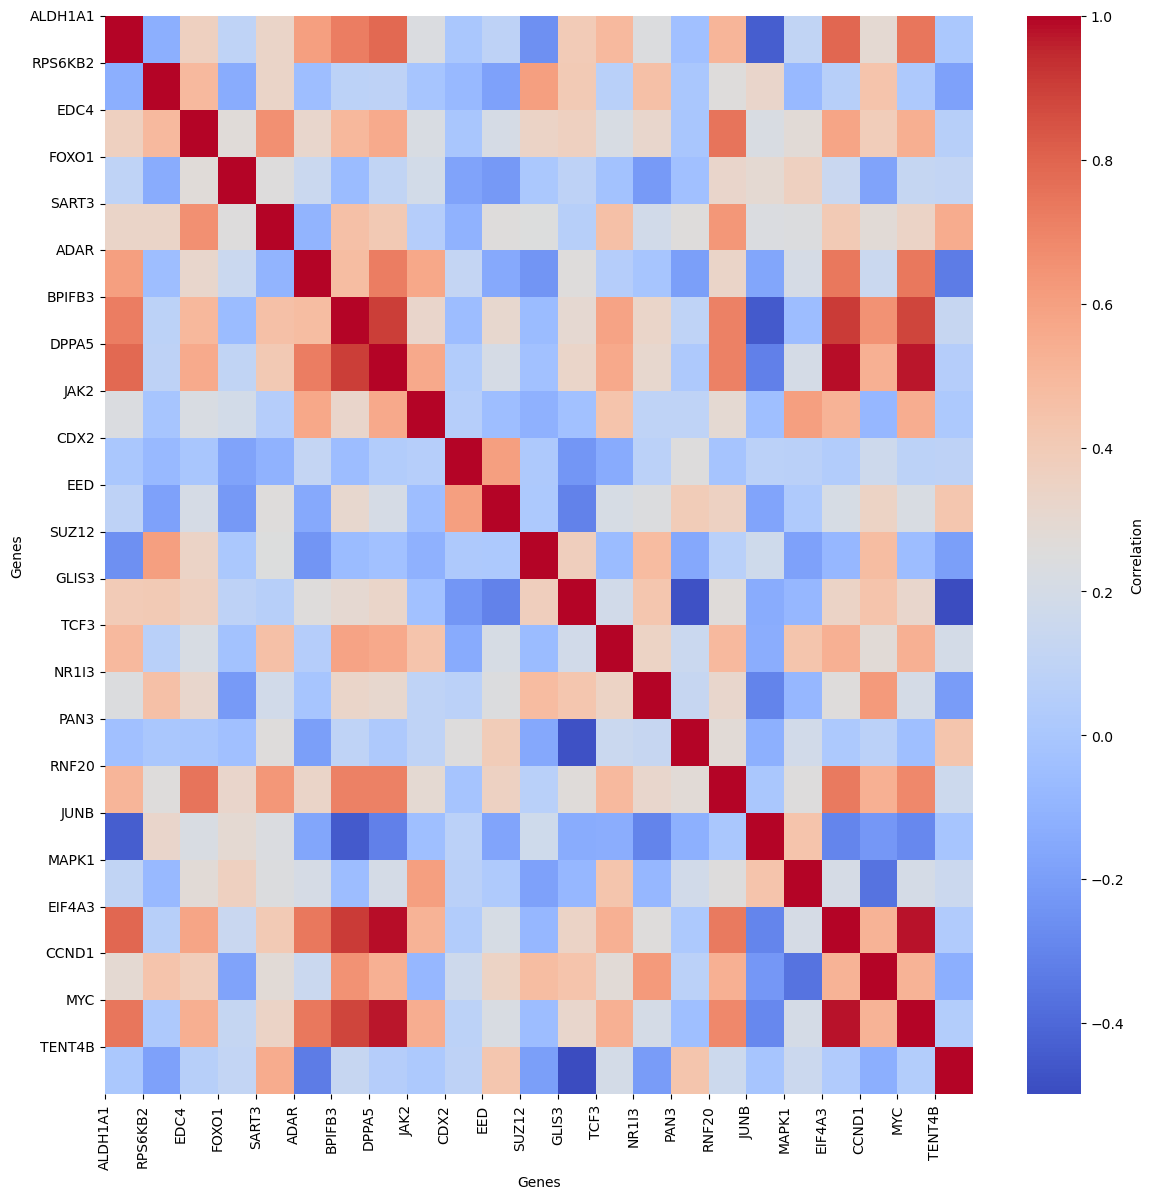

In [88]:
#correlation matrix for reverese

# Assuming 'gene_labels' is a list of gene labels corresponding to 'common_top_gene_indices_f_and_r'
gene_labels = finalgenes  # replace with actual gene labels

A = A_new[non_zero_cols_r]
Acorr = np.corrcoef(A[common_top_pert_indices_f_and_r][:, common_top_gene_indices_f_and_r], rowvar=False)

fig, axs = plt.subplots(1, 1, figsize=(14, 14))

sns.heatmap(Acorr, cmap='coolwarm', ax=axs, cbar_kws={'label': 'Correlation'})
axs.set_xlabel('Genes')
axs.set_ylabel('Genes')

# Add gene labels after plotting the heatmap
axs.set_xticks(range(len(gene_labels)))
axs.set_yticks(range(len(gene_labels)))
axs.set_xticklabels(gene_labels, rotation=90)
axs.set_yticklabels(gene_labels, rotation=0)

plt.show()

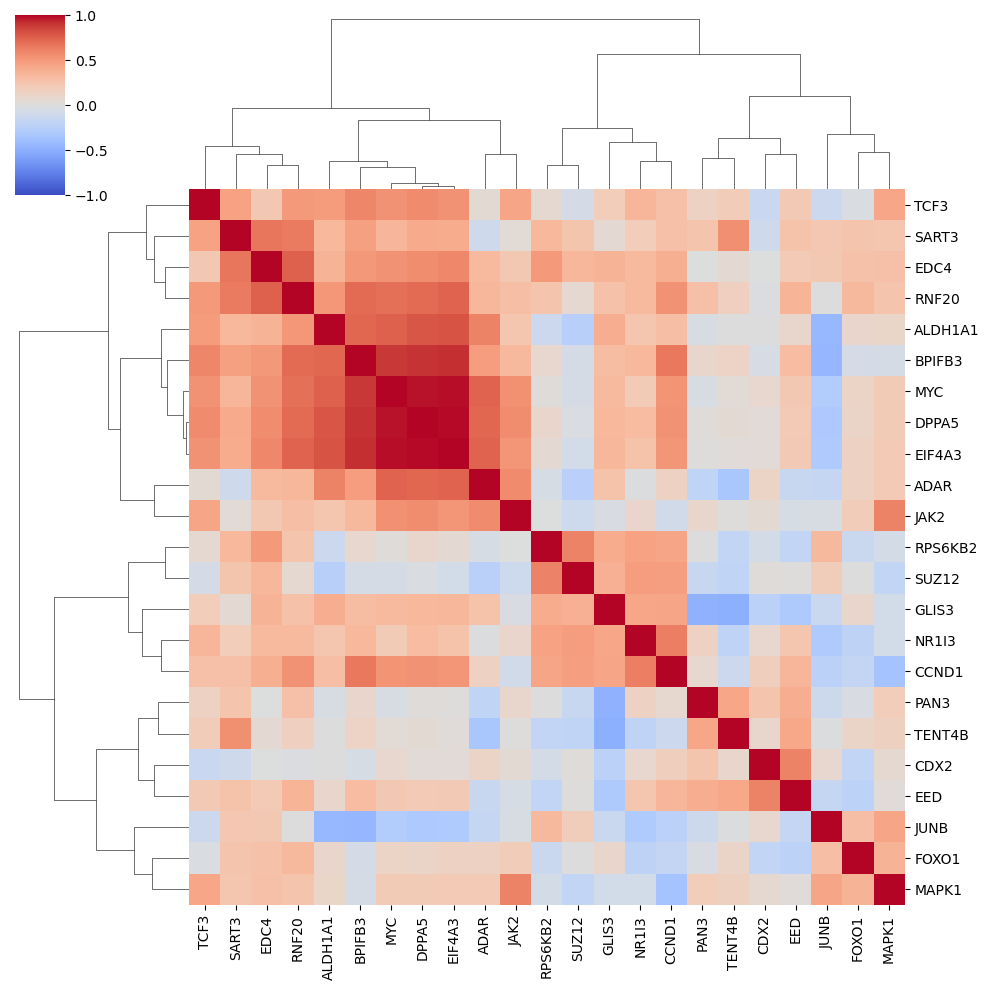

In [89]:


# Your correlation matrix and a list of labels corresponding to the indices

# Creating the linkage matrix for clustering
row_linkage = linkage(Acorr, method='ward')
col_linkage = linkage(Acorr.T, method='ward')  # Transpose for column clustering

# Creating a clustermap with labels
sns.clustermap(Acorr, cmap='coolwarm', figsize=(10, 10),
               row_cluster=True, col_cluster=True,
               row_linkage=row_linkage, col_linkage=col_linkage,
               xticklabels=gene_labels, yticklabels=gene_labels,vmin=-1, vmax=1)
plt.show()


In [90]:
gene_pair_index_r = []
for pair in gene_pairs_r:
    i,j = pair
    gene_pair_index_r.append([reversed_pair_mapping[i], reversed_pair_mapping[j]])
print(gene_pair_index_r)


print(pairgenes_r)
pairgenes_r = []
for i in range(len(nonzero_pairs)):
    gene1, gene2 = nonzero_pairs[i]
    if gene1 != gene2 and gene1 < gene2:
        pairgenes_r.append(gene1)
        pairgenes_r.append(gene2)

pairgenes_r = np.asarray(list(set(pairgenes_r)))
print(pairgenes_r)
len(pairgenes_r)



input_genes = condensed_gene_perts.copy()
for i in range(len(input_genes)):
    input_genes[i] = input_genes[i][:-3]

perts_to_eid = {
    gene: item['element']
    for gene in input_genes
    for item in gene_dict
    if gene in item['last_two_words']
#     if gene in item['last_two_words'].split(',')
}
pert_to_gene_indices = {gene: pert_column_ids.get_loc(eid) for gene, eid in perts_to_eid.items() if eid in pert_column_ids}

    
common_top_genes_f_and_r = condensed_gene_perts[non_zero_cols_r][pairgenes_r]
for i in range(len(common_top_genes_f_and_r)):
    common_top_genes_f_and_r[i] = common_top_genes_f_and_r[i][:-3]   
# Assuming common_top_genes_f_and_r is a list of genes and pert_to_gene_indices is the dictionary mapping genes to indices

# List to store corresponding gene indices
common_top_gene_indices_f_and_r, common_top_pert_indices_f_and_r = [], []
count  = 0
finalgenes, finalgeneindex = [], []
# Iterate over each gene in common_top_genes_f_and_r
for gene in common_top_genes_f_and_r:
    # Check if the gene exists in pert_to_gene_indices
    if gene in pert_to_gene_indices:
        # Append the corresponding index to the list
        finalgenes.append(gene)
        finalgeneindex.append(pairgenes_r[count])
        common_top_gene_indices_f_and_r.append(pert_to_gene_indices[gene])
        common_top_pert_indices_f_and_r.append(pairgenes_r[count])
    else: print(gene)
    count += 1

# Print the list of gene indices
print("Corresponding gene indices:", common_top_gene_indices_f_and_r)
print("Corresponding pert indices:", common_top_pert_indices_f_and_r)

indtoind  = {finalgeneindex[i]: i for i in range(len(finalgeneindex))}

count = 0
newpairs = []
for pair in gene_pair_index_r:
    i,j = pair
    if i in finalgeneindex and j in finalgeneindex:
        newind1, newind2 = indtoind[i], indtoind[j]
#         print(Acorr[ind1,ind2])
        newpairs.append([newind1, newind2])
        count += 1
    else: print(i,j)


[[np.int64(25), np.int64(23)], [np.int64(34), np.int64(8)], [np.int64(48), np.int64(146)], [np.int64(50), np.int64(48)], [np.int64(54), np.int64(115)], [np.int64(59), np.int64(85)], [np.int64(59), np.int64(115)], [np.int64(60), np.int64(58)], [np.int64(68), np.int64(50)], [np.int64(68), np.int64(146)], [np.int64(77), np.int64(115)], [np.int64(85), np.int64(54)], [np.int64(87), np.int64(77)], [np.int64(87), np.int64(146)], [np.int64(91), np.int64(146)], [np.int64(103), np.int64(50)], [np.int64(103), np.int64(146)], [np.int64(104), np.int64(50)], [np.int64(109), np.int64(50)], [np.int64(115), np.int64(20)], [np.int64(117), np.int64(77)], [np.int64(125), np.int64(50)], [np.int64(130), np.int64(34)], [np.int64(134), np.int64(7)], [np.int64(137), np.int64(77)], [np.int64(146), np.int64(23)], [np.int64(146), np.int64(25)], [np.int64(150), np.int64(25)]]
[130 134   7   8 137 146  20 150  23  25  34  48  50  54  58  59  60  68
  77  85  87  91 103 104 109 115 117 125]
[130 134   7   8 137 146 

In [91]:
# Create the finalgenes_ann list
finalgenes_ann = []

# Populate finalgenes_ann with corresponding annotations from condensed_gene_perts
for gene in finalgenes:
    for annotated_gene in condensed_gene_perts:
        if gene in annotated_gene:
            finalgenes_ann.append(annotated_gene)
            break

# Print the finalgenes_ann list
print("\nFinalgenes_ann list with annotations:")
print(finalgenes_ann)


Finalgenes_ann list with annotations:
[np.str_('ALDH1A1 kd'), np.str_('RPS6KB2 kd'), np.str_('EDC4 kd'), np.str_('FOXO1 kd'), np.str_('SART3 kd'), np.str_('ADAR kd'), np.str_('BPIFB3 kd'), np.str_('DPPA5 kd'), np.str_('JAK2 kd'), np.str_('CDX2 oe'), np.str_('EED kd'), np.str_('SUZ12 kd'), np.str_('GLIS3 kd'), np.str_('TCF3 kd'), np.str_('NR1I3 kd'), np.str_('PAN3 kd'), np.str_('RNF20 kd'), np.str_('JUNB kd'), np.str_('MAPK1 kd'), np.str_('EIF4A3 kd'), np.str_('CCND1 oe'), np.str_('MYCN kd'), np.str_('TENT4B oe')]


1 JAK2 DPPA5
2 EED SART3
3 SUZ12 EED
4 GLIS3 CCND1
5 NR1I3 SUZ12
6 NR1I3 SART3
7 PAN3 GLIS3
8 RNF20 SART3
9 JUNB SUZ12
10 JUNB SART3
11 MAPK1 SUZ12
12 EIF4A3 SUZ12
13 CCND1 ADAR
14 TENT4B SUZ12
15 ALDH1A1 CDX2
16 RPS6KB2 EDC4
17 SART3 DPPA5
18 SART3 JAK2
19 BPIFB3 JAK2


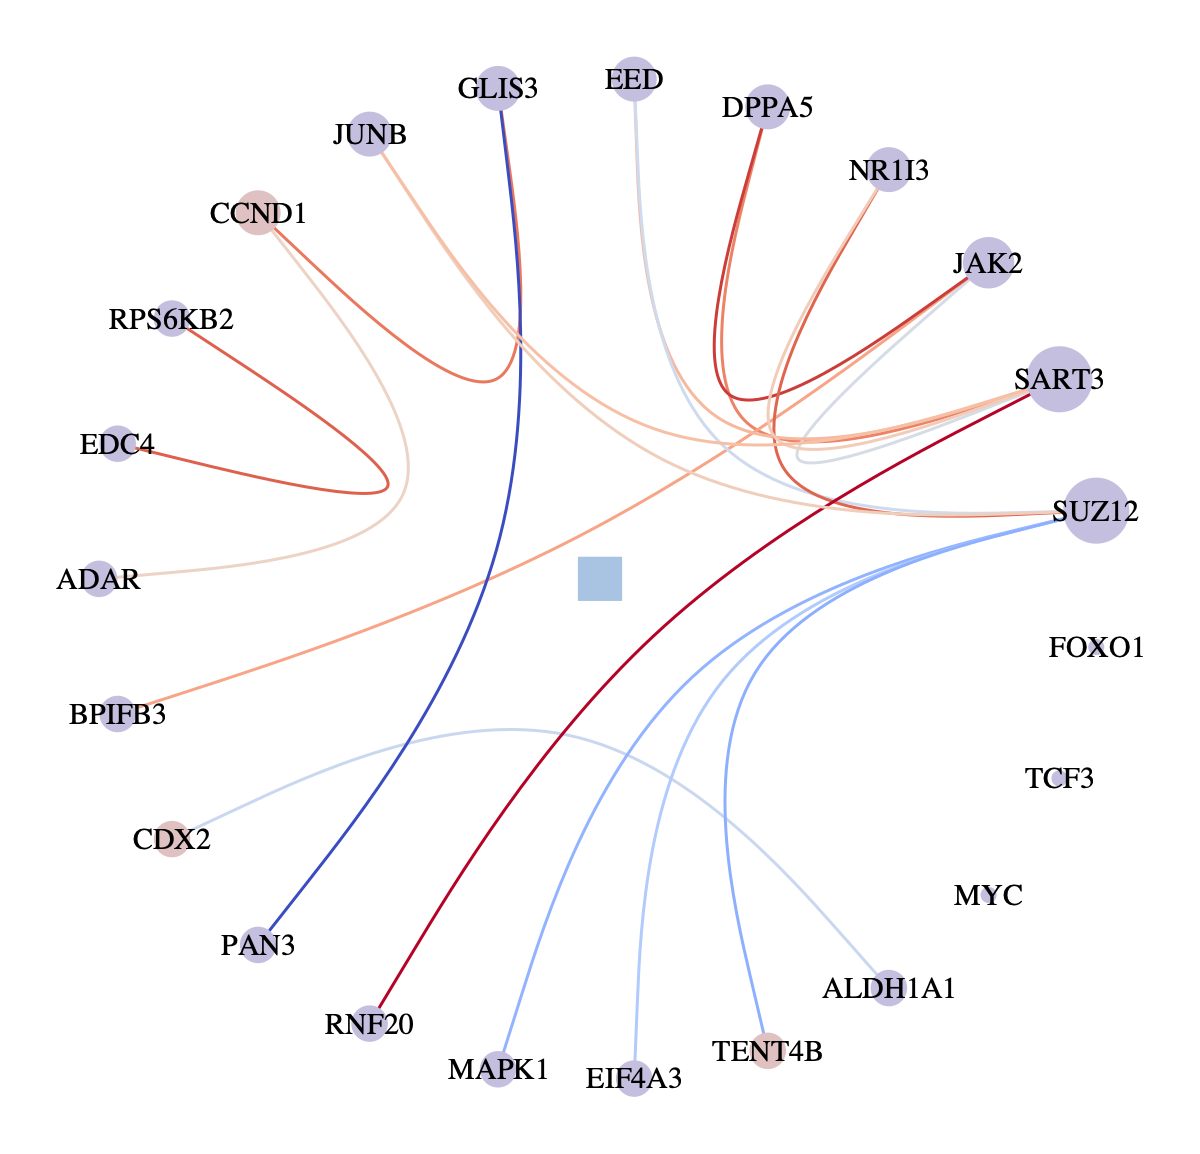

(<VertexPropertyMap object with value type 'vector<double>', for Graph 0x164749f90, at 0x1687f4520>,
 <GraphView object, directed, with 24 vertices and 23 edges, edges filtered by <EdgePropertyMap object with value type 'bool', for Graph 0x1687f0730, at 0x1687f40c0>, vertices filtered by <VertexPropertyMap object with value type 'bool', for Graph 0x1687f0730, at 0x1687f41a0>, at 0x1687f0730>,
 <VertexPropertyMap object with value type 'vector<double>', for Graph 0x1687f0730, at 0x1687f4210>)

In [92]:
# reverse


def create_graph_from_corr_matrix_gt(pairs, newfingenes):
    # Create an empty graph
    g = gt.Graph(directed=False)
    vertices = [g.add_vertex() for _ in range(len(newfingenes))]
    
    gene_pairs_r = []
    
    weights = g.new_edge_property("double")
    count = 0
    gene_pairs_r = []
    for pair in pairs:
        i,j = pair
        e = g.add_edge(vertices[i], vertices[j])
        weights[e] = Acorr[i][j]
        count += 1
        print(count, finalgenes[i] +' '+ finalgenes[j])
        gene_pairs_r.append(finalgenes[i] +' '+ finalgenes[j])
        
        
    g.edge_properties["weight"] = weights
    
     
    
    return g, weights, gene_pairs_r


g, weights, gene_pairs_r_final = create_graph_from_corr_matrix_gt(np.array(newpairs), finalgenes)
v_labels = g.new_vertex_property("string")
count = 0
for v in g.vertices():
    genestr = finalgenes[count]
    v_labels[v] = genestr

    count += 1
g.vertex_properties["labels"] = v_labels

# Create a vertex property map to store the colors


oe_color = "indianred"
kd_color = "slateblue"
# Function to adjust hue to pastel
def make_pastel(color):
    rgb = mcolors.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(*rgb)
    s *= 0.6  # Reduce saturation
    l *= 1.4  # Increase lightness
    l = min(l, 1.0)  # Ensure lightness does not exceed 1.0
    pastel_rgb = colorsys.hls_to_rgb(h, l, s)
    return pastel_rgb

# Adjust colors to pastel
oe_color_pastel = make_pastel(oe_color)
kd_color_pastel = make_pastel(kd_color)

# Apply colors to vertices
vertex_colors = g.new_vertex_property("vector<float>")
count = 0
for v in g.vertices():
    if finalgenes_ann[count][-2:] == 'kd':
        vertex_colors[v] = kd_color_pastel
    else:
        vertex_colors[v] = oe_color_pastel
    count += 1

# Set the vertex property map as the vertex color property
g.vertex_properties["color"] = vertex_colors


state = gt.minimize_nested_blockmodel_dl(g,
                                         state_args=dict(base_type=gt.LayeredBlockState,
                                                         state_args=dict(ec=weights, layers=False)))

# state = gt.minimize_nested_blockmodel_dl(g)

state.draw(edge_color=g.ep.weight, edge_gradient=[],
           ecmap=(matplotlib.cm.coolwarm, 1.), edge_pen_width=1.5,
           output_size=(600, 600),vertex_fill_color=g.vertex_properties["color"], vertex_color=g.vertex_properties["color"] ,\
           vertex_text=g.vertex_properties["labels"],\
           vertex_text_color='black',vertex_font_size=15,vertex_text_position=-3)


state.draw(edge_color=g.ep.weight, edge_gradient=[],
           ecmap=(matplotlib.cm.coolwarm, 1.), edge_pen_width=1.5,
           output_size=(500, 500),vertex_fill_color=g.vertex_properties["color"], vertex_color=g.vertex_properties["color"] ,\
           vertex_text=g.vertex_properties["labels"],\
           vertex_text_color='black',vertex_font_size=15,vertex_text_position=-3, output="reverse_net_ib.pdf")
        

    

In [101]:
np.save('gene_pairs_f_final',gene_pairs_f_final)
np.save('gene_pairs_r_final',gene_pairs_r_final)